# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [3]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.3 MB/s eta 0:00:00


In [4]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

torch.manual_seed(42)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [5]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

# CARGAR IMAGENES DE ENTRENAMIENTO Y PRUEBA Y GENERAR UN SUBCONJUNTO
trainset_completo = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

TAM_TRAIN = 5000
TAM_VAL = 1000

train_subset, val_subset, _ = random_split(
    trainset_completo,
    [
        TAM_TRAIN,
        TAM_VAL,
        len(trainset_completo) - TAM_TRAIN - TAM_VAL,
    ],
    generator=torch.Generator().manual_seed(42),
)



nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

print(f"Tamano Subset Entrenamiento: {len(train_subset)} imágenes")
print(f"Tamano Subset Validación: {len(val_subset)} imágenes")


100%|██████████| 170M/170M [00:36<00:00, 4.72MB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000
Tamano Subset Entrenamiento: 5000 imágenes
Tamano Subset Validación: 1000 imágenes


### 1.1 Subconjuntos de trabajo



Entrenamiento: 5000 imagenes  |  Validacion: 1000  |  Prueba: 10000


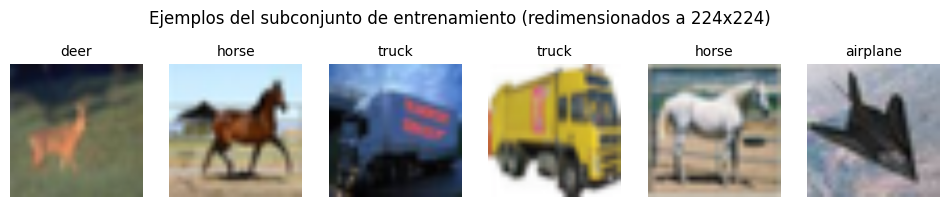

In [6]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [7]:
# COMPLETAR construir_resnet18(n_clases=10)
def construir_resnet18(n_clases=10):
    modelo = models.resnet18(weights="DEFAULT")
    modelo.fc = nn.Linear(modelo.fc.in_features, n_clases)
    return modelo.to(DISPOSITIVO)

In [8]:
# COMPLETAR  construir_efficientnet_b0(n_clases=10)
def construir_efficientnet_b0(n_clases=10):
    modelo = models.efficientnet_b0(weights="DEFAULT")
    modelo.classifier[1] = nn.Linear(
        modelo.classifier[1].in_features,
        n_clases,
    )
    return modelo.to(DISPOSITIVO)

In [9]:
modelo_resnet = construir_resnet18(n_clases=10)
modelo_efficientnet = construir_efficientnet_b0(n_clases=10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 73.6MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 142MB/s]


In [10]:
print("ResNet-18 y EfficientNet-B0 listos en", DISPOSITIVO)

ResNet-18 y EfficientNet-B0 listos en cuda


---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [11]:
def crear_metricas(n_clases=10):
    return {
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los van a necesitar tal cual para el reporte de diseno (Parte 7).


In [13]:
N_EPOCAS = 5
LEARNING_RATE = 0.0001

def entrenar_modelo(modelo, nombre_modelo):
    perdida_fn = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

    metricas_train = crear_metricas()
    metricas_val = crear_metricas()
    historial = []

    for epoca in range(1, N_EPOCAS + 1):
        if DISPOSITIVO.type == "cuda":
            torch.cuda.synchronize()
        inicio = time.perf_counter()

        resultados_train = correr_epoca(
            modelo,
            train_loader,
            perdida_fn,
            metricas_train,
            optimizador=optimizador,
        )

        resultados_val = correr_epoca(
            modelo,
            val_loader,
            perdida_fn,
            metricas_val,
            optimizador=None,
        )

        if DISPOSITIVO.type == "cuda":
            torch.cuda.synchronize()
        duracion = time.perf_counter() - inicio

        registro = {
            "modelo": nombre_modelo,
            "epoca": epoca,
            "tiempo_seg": duracion,
        }
        registro.update({
            f"train_{metrica}": valor
            for metrica, valor in resultados_train.items()
        })
        registro.update({
            f"val_{metrica}": valor
            for metrica, valor in resultados_val.items()
        })
        historial.append(registro)

        print(
            f"{nombre_modelo} | Época {epoca}/{N_EPOCAS} "
            f"| train loss: {resultados_train['loss']:.4f} "
            f"| train accuracy: {resultados_train['accuracy']:.4f} "
            f"| val loss: {resultados_val['loss']:.4f} "
            f"| val accuracy: {resultados_val['accuracy']:.4f} "
            f"| duración: {duracion:.1f} s"
        )

    return pd.DataFrame(historial)

In [14]:
historial_resnet = entrenar_modelo(
    modelo_resnet,
    "ResNet-18"
)

historial_efficientnet = entrenar_modelo(
    modelo_efficientnet,
    "EfficientNet-B0",
)

df_historial = pd.concat(
    [historial_resnet, historial_efficientnet],
    ignore_index=True,
)

df_historial

ResNet-18 | Época 1/5 | train loss: 0.7762 | train accuracy: 0.7473 | val loss: 0.3866 | val accuracy: 0.8734 | duración: 21.0 s
ResNet-18 | Época 2/5 | train loss: 0.1827 | train accuracy: 0.9505 | val loss: 0.3626 | val accuracy: 0.8724 | duración: 19.5 s
ResNet-18 | Época 3/5 | train loss: 0.0591 | train accuracy: 0.9909 | val loss: 0.3548 | val accuracy: 0.8928 | duración: 19.5 s
ResNet-18 | Época 4/5 | train loss: 0.0250 | train accuracy: 0.9976 | val loss: 0.3420 | val accuracy: 0.8895 | duración: 19.8 s
ResNet-18 | Época 5/5 | train loss: 0.0184 | train accuracy: 0.9981 | val loss: 0.3339 | val accuracy: 0.8818 | duración: 19.2 s
EfficientNet-B0 | Época 1/5 | train loss: 1.3002 | train accuracy: 0.6268 | val loss: 0.5072 | val accuracy: 0.8483 | duración: 29.7 s
EfficientNet-B0 | Época 2/5 | train loss: 0.4164 | train accuracy: 0.8735 | val loss: 0.3481 | val accuracy: 0.9033 | duración: 28.8 s
EfficientNet-B0 | Época 3/5 | train loss: 0.2242 | train accuracy: 0.9337 | val loss:

,modelo,epoca,tiempo_seg,train_accuracy,train_precision,train_recall,train_f1,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_loss
0,ResNet-18,1,20.987114,0.747278,0.751736,0.747278,0.747794,0.776181,0.873389,0.873718,0.873389,0.872038,0.386597
1,ResNet-18,2,19.503581,0.950484,0.950668,0.950484,0.950523,0.182732,0.872379,0.874619,0.872379,0.871291,0.362554
2,ResNet-18,3,19.469789,0.990923,0.991009,0.990923,0.990962,0.059091,0.892804,0.895903,0.892804,0.892647,0.354823
3,ResNet-18,4,19.795476,0.997595,0.997562,0.997595,0.997576,0.025035,0.889528,0.891817,0.889528,0.889097,0.341955
4,ResNet-18,5,19.173996,0.998052,0.998038,0.998052,0.998042,0.018449,0.881763,0.881102,0.881763,0.880760,0.333866
5,EfficientNet-B0,1,29.690115,0.626760,0.636592,0.626760,0.620026,1.300197,0.848276,0.848472,0.848276,0.845743,0.507219
6,EfficientNet-B0,2,28.842957,0.873528,0.873801,0.873528,0.873505,0.416427,0.903320,0.905101,0.903320,0.902988,0.348063
7,EfficientNet-B0,3,28.704063,0.933702,0.934013,0.933702,0.933819,0.224222,0.902163,0.902293,0.902163,0.901486,0.295121
8,EfficientNet-B0,4,28.550957,0.959792,0.959866,0.959792,0.959799,0.139875,0.913949,0.915143,0.913949,0.913406,0.297199
9,EfficientNet-B0,5,28.670363,0.967042,0.967101,0.967042,0.967068,0.110076,0.910764,0.911794,0.910764,0.910984,0.301465


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


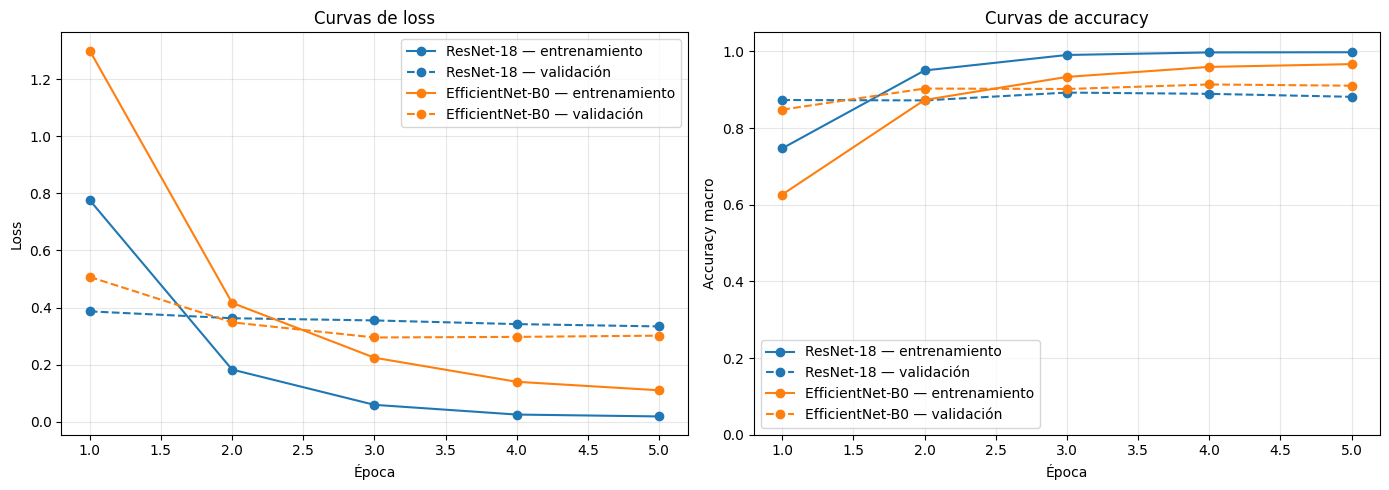

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

colores = {
    "ResNet-18": "tab:blue",
    "EfficientNet-B0": "tab:orange",
}

for nombre_modelo, color in colores.items():
    datos = (
        df_historial[df_historial["modelo"] == nombre_modelo]
        .sort_values("epoca")
    )

    # Loss
    axs[0].plot(
        datos["epoca"],
        datos["train_loss"],
        color=color,
        linestyle="-",
        marker="o",
        label=f"{nombre_modelo} — entrenamiento",
    )
    axs[0].plot(
        datos["epoca"],
        datos["val_loss"],
        color=color,
        linestyle="--",
        marker="o",
        label=f"{nombre_modelo} — validación",
    )

    # Accuracy
    axs[1].plot(
        datos["epoca"],
        datos["train_accuracy"],
        color=color,
        linestyle="-",
        marker="o",
        label=f"{nombre_modelo} — entrenamiento",
    )
    axs[1].plot(
        datos["epoca"],
        datos["val_accuracy"],
        color=color,
        linestyle="--",
        marker="o",
        label=f"{nombre_modelo} — validación",
    )

axs[0].set_title("Curvas de loss")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].set_title("Curvas de accuracy")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Accuracy macro")
axs[1].set_ylim(0, 1.05)
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [16]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.890,0.891,0.890,0.890
1,EfficientNet-B0,0.915,0.915,0.915,0.915


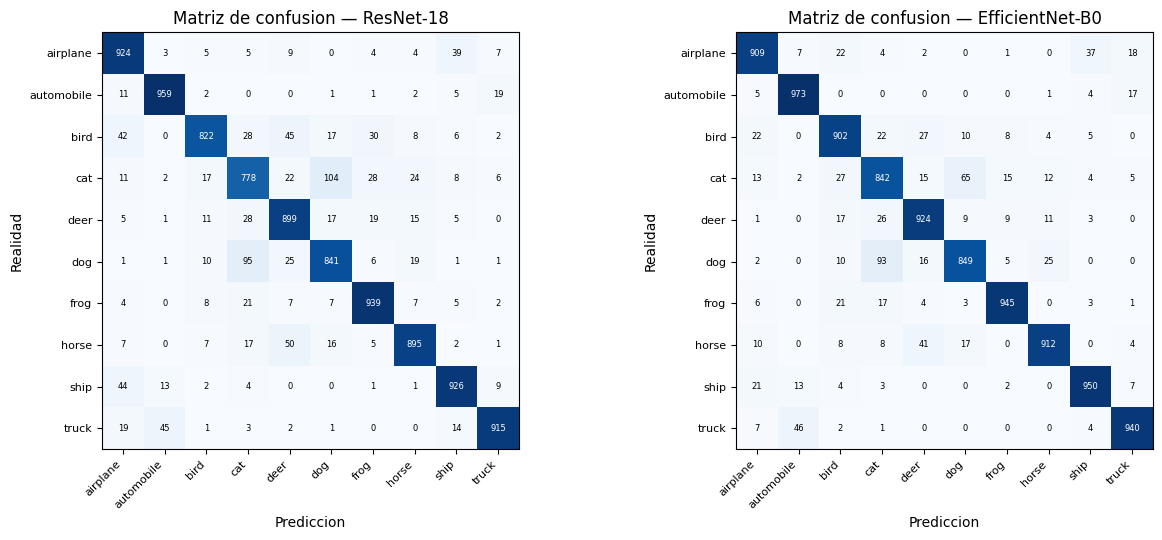

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


---
## 7. Reporte de diseño (completar en equipo)

Esta seccion es, literalmente, la evidencia **"Reporte de diseño"** del temario de la Unidad 1. Respondan cada punto con base en lo que observaron arriba — pueden editar esta celda de markdown directamente o copiar las respuestas a un documento aparte.

**1. Arquitectura y justificación**

> Para este problema de clasificacion el modelo recomendado es EfficientNet-B0 En el conjunto de prueba obtuvo accuracy, precisión, recall y F1 macro de 0.915, frente a 0.890 de ResNet-18. EfficientNet-B0 logró mejores métricas aunque su tiempo de entrenamiento por época fue mayor.

**2. Hiperparámetros usados**

> Learning rate: `0.0001`  ·  Optimizador: `Adam`  ·  Épocas: `5`  ·  Batch size: `32`  ·  Tamaño del subconjunto de entrenamiento: `5000`  ·  Pesos iniciales: preentrenados (ImageNet)

**3. Estrategia de entrenamiento**

> Se entrenaron los modelos usando GPU. Las epocas para ResNet tardaron aproximadamente entre 19 a 20 segundos y las epocas para EfficientNet tardaron aproximadamente entre 28 y 29 segundos. Con mas tiempo,  aumentaríamos primero el tamaño del subconjunto de entrenamiento para mejorar la generalización y comparar el efecto de disponer de más datos.

**4. Diagnóstico de las curvas (conexión con 1.4)**

> ResNet-18 mostró señales de sobreajuste, ya que su accuracy de entrenamiento fue 0.998, mientras que la de validación fue 0.882. Por otra parte, EfficientNet-B0 generalizó mejor, la diferencia final entre accuracy de entrenamiento (0.967) y validación (0.911) fue menor. Aun que sus curvas muestran señales leves de sobreajuste al final pero el resultado fue en general mejor que el otro modelo.

**5. Capacidad vs. eficiencia (conexión con 1.3)**

> ResNet-18 tiene aproximadamente 11.18 millones de parámetros y EfficientNet-B0 aproximadamente 4.02 millones. EfficientNet-B0 obtuvo mayor accuracy de prueba con alrededor de 64% menos parámetros. Aun que, tardó más por época (28s a comparacion de 19s), así que ofrece mejor relación entre accuracy y número de parámetros, pero no fue más rápido de entrenar.

**6. Errores más frecuentes**
> *(Con las matrices de confusión de la Parte 6: ¿qué par de clases confunde más cada modelo? ¿Tiene sentido esa confusión dado lo que representan esas clases?)*

> Para ambos modelos el par de clases mas confundidos fueron cat con dog, con 199 errores de ResNet y 158 errores de EfficientNet. Esto tiene sentido ya que estas dos clases son similares visualmente con muy pequeñas diferencias.

In [19]:
import numpy as np

def mostrar_par_mas_confundido(matriz, nombres_clases):
    matriz = np.asarray(matriz)
    i, j = np.triu_indices(len(nombres_clases), k=1)
    errores_por_par = matriz[i, j] + matriz[j, i]
    mejor = errores_por_par.argmax()
    clase_a, clase_b = i[mejor], j[mejor]

    print(
        f"{nombres_clases[clase_a]} ↔ {nombres_clases[clase_b]}: "
        f"{int(matriz[clase_a, clase_b])} y "
        f"{int(matriz[clase_b, clase_a])} errores "
        f"(total: {int(errores_por_par[mejor])})"
    )

mostrar_par_mas_confundido(matriz_resnet, nombres_clases)
mostrar_par_mas_confundido(matriz_efficientnet, nombres_clases)

cat ↔ dog: 104 y 95 errores (total: 199)
cat ↔ dog: 65 y 93 errores (total: 158)


---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [x] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [x] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [x] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [x] Reporte de diseno (Parte 7) completado por el equipo.
- [x] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
